In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import inspect
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from itertools import product
import shutup
from sklearn.preprocessing import StandardScaler
shutup.please()

In [3]:
df = pd.read_csv('datasets/winequality-red.csv')
df.columns.isnull()

array([False, False, False, False, False, False, False, False, False,
       False, False, False])

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.neighbors import KNeighborsRegressor


def knn_regressor(
    X,
    y,
    test_size=0.25,
    n_neighbors_range=range(1, 15),
    monte_carlo_iterations=49,
    validation_size=None,  # NEW: for 3-way split
    cv=None,               # NEW: number of folds
    plot_results=True
):
    """
    KNN regression supporting pseudo Monte Carlo, 3-way split, or K-Fold CV.
    """

    cv_train = pd.DataFrame()
    cv_test = pd.DataFrame()
    cv_val = pd.DataFrame()  # validation scores

    # ----------------------------
    # SINGLE SPLIT (baseline curve)
    # ----------------------------
    if validation_size is None:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42
        )
        use_validation = False
    else:
        X_train_val, X_test, y_train_val, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42
        )
        val_fraction = validation_size / (1 - test_size)
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=val_fraction, random_state=42
        )
        use_validation = True
        print(f"Train size: {len(X_train)}, Validation size: {len(X_val)}, Test size: {len(X_test)}")

    # Single split accuracy curve
    train_scores = []
    test_scores = []
    val_scores = []

    for n in n_neighbors_range:
        reg = KNeighborsRegressor(n_neighbors=n)
        reg.fit(X_train, y_train)

        train_scores.append(reg.score(X_train, y_train))
        test_scores.append(reg.score(X_test, y_test))
        if use_validation:
            val_scores.append(reg.score(X_val, y_val))

    plt.figure(figsize=(12, 5))
    plt.plot(n_neighbors_range, train_scores, label="Training $R^2$")
    plt.plot(n_neighbors_range, test_scores, label="Test $R^2$")
    if use_validation:
        plt.plot(n_neighbors_range, val_scores, label="Validation $R^2$")
    plt.xlabel("n_neighbors")
    plt.ylabel("Accuracy ($R^2$)")
    plt.title("KNN Regression Accuracy vs. n_neighbors (Single Split)")
    plt.legend()
    plt.show()

    # ----------------------------
    # K-FOLD CROSS VALIDATION
    # ----------------------------
    if cv is not None:
        kf = KFold(n_splits=cv, shuffle=True, random_state=42)
        for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
            X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
            y_train_cv, y_test_cv = y[train_idx], y[test_idx]

            train_fold = []
            test_fold = []

            for n in n_neighbors_range:
                reg = KNeighborsRegressor(n_neighbors=n)
                reg.fit(X_train_cv, y_train_cv)
                train_fold.append(reg.score(X_train_cv, y_train_cv))
                test_fold.append(reg.score(X_test_cv, y_test_cv))

            cv_train[fold] = train_fold
            cv_test[fold] = test_fold

        title = f"{cv}-Fold CV KNN Regression Accuracy"

    # ----------------------------
    # 3-WAY SPLIT MONTE CARLO
    # ----------------------------
    elif validation_size is not None:
        for seed in range(1, monte_carlo_iterations + 1):
            X_train_val, X_test, y_train_val, y_test = train_test_split(
                X, y, test_size=test_size, random_state=seed
            )
            val_fraction = validation_size / (1 - test_size)
            X_train, X_val, y_train, y_val = train_test_split(
                X_train_val, y_train_val, test_size=val_fraction, random_state=seed
            )

            train_fold = []
            test_fold = []
            val_fold = []

            for n in n_neighbors_range:
                reg = KNeighborsRegressor(n_neighbors=n)
                reg.fit(X_train, y_train)
                train_fold.append(reg.score(X_train, y_train))
                test_fold.append(reg.score(X_test, y_test))
                val_fold.append(reg.score(X_val, y_val))

            cv_train[seed] = train_fold
            cv_test[seed] = test_fold
            cv_val[seed] = val_fold

        title = "3-Way Split Monte Carlo KNN Regression Accuracy"

    # ----------------------------
    # PSEUDO MONTE CARLO (default)
    # ----------------------------
    else:
        for seed in range(1, monte_carlo_iterations + 1):
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=test_size, random_state=seed
            )

            train_fold = []
            test_fold = []

            for n in n_neighbors_range:
                reg = KNeighborsRegressor(n_neighbors=n)
                reg.fit(X_train, y_train)
                train_fold.append(reg.score(X_train, y_train))
                test_fold.append(reg.score(X_test, y_test))

            cv_train[seed] = train_fold
            cv_test[seed] = test_fold

        title = "Pseudo Monte Carlo KNN Regression Accuracy"

    # ----------------------------
    # PLOT MEAN + ERROR
    # ----------------------------
    plt.figure(figsize=(12, 5))
    plt.errorbar(n_neighbors_range, cv_train.mean(axis=1), yerr=cv_train.std(axis=1), label="Training $R^2$")
    plt.errorbar(n_neighbors_range, cv_test.mean(axis=1), yerr=cv_test.std(axis=1), label="Test $R^2$")
    if not cv_val.empty:
        plt.errorbar(n_neighbors_range, cv_val.mean(axis=1), yerr=cv_val.std(axis=1), label="Validation $R^2$")
    plt.xlabel("n_neighbors")
    plt.ylabel("Accuracy ($R^2$)")
    plt.title(title)
    plt.legend()
    plt.show()

    return cv_train, cv_test, cv_val

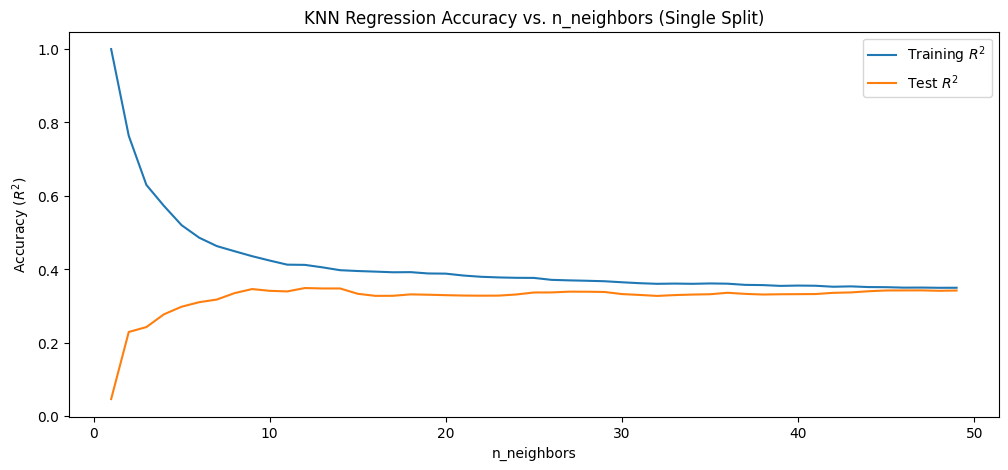

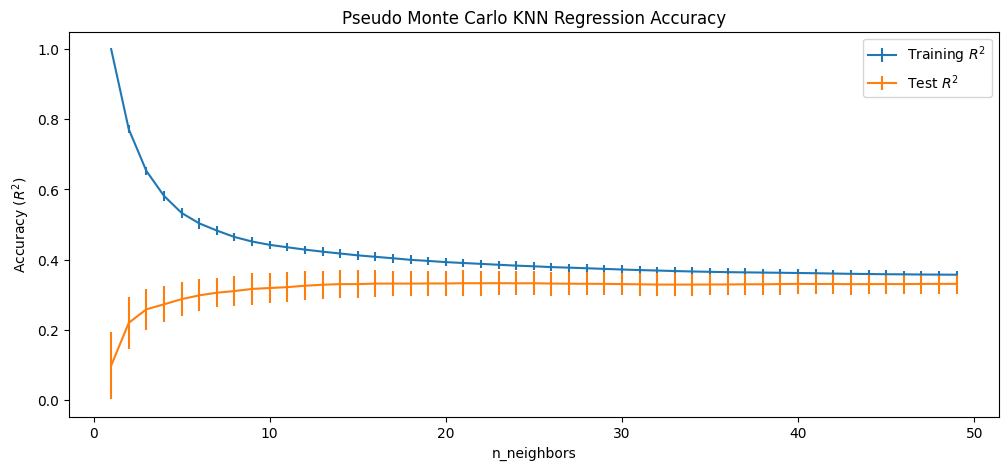

KeyError: 0

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns='quality')
y = df['quality']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run KNN for k=5 with single split
train_scores, test_scores, _ = knn_regressor(
    X=X_scaled, 
    y=y, 
    n_neighbors_range=range(1,50), 
    monte_carlo_iterations=50,

)



print(f"Training R²: {train_scores[0]:.3f}")
print(f"Test R²: {test_scores[0]:.3f}")

Training R²: 0.412
Test R²: 0.349
Best k: 12 with Test R²: 0.349


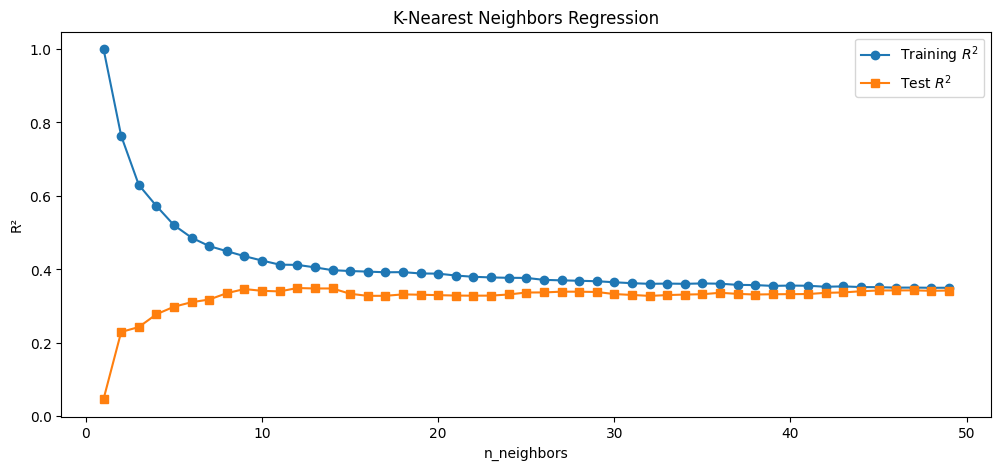

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
X = df.drop(columns='quality')
y = df['quality']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

knn = KNeighborsRegressor(n_neighbors=12)
knn.fit(X_train, y_train)
train_score = knn.score(X_train, y_train)
test_score = knn.score(X_test, y_test)
print(f"Training R²: {train_score:.3f}")
print(f"Test R²: {test_score:.3f}")

training_acc= []
test_acc = []
neighbrs_range = range(1, 50)
for k in neighbrs_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    training_acc.append(knn.score(X_train, y_train))
    test_acc.append(knn.score(X_test, y_test))
plt.figure(figsize=(12, 5))
plt.plot(neighbrs_range, training_acc, label="Training $R^2$", marker='o')
plt.plot(neighbrs_range, test_acc, label="Test $R^2$", marker='s')
plt.xlabel("n_neighbors")
plt.ylabel("R²")
plt.title("K-Nearest Neighbors Regression")
plt.legend()

best_k = neighbrs_range[np.argmax(test_acc)]
print(f"Best k: {best_k} with Test R²: {max(test_acc):.3f}")

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print(f'coefficients: {lin_reg.coef_}')
print(f'intercept: {lin_reg.intercept_}')

train_score = lin_reg.score(X_train, y_train)
test_score = lin_reg.score(X_test, y_test)
print(f"Linear Regression Training R²: {train_score:.3f}")
print(f"Linear Regression Test R²: {test_score:.3f}")

ypred = lin_reg.predict(X_test)
# Visualize
plt.figure(figsize=(12, 5))


coefficients: [ 0.03804852 -0.18056018 -0.02607653  0.01248727 -0.08260099  0.05237372
 -0.1201705  -0.03060987 -0.053083    0.13892165  0.30492871]
intercept: 5.633957834515446
Linear Regression Training R²: 0.355
Linear Regression Test R²: 0.372


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

lin_reg = Ridge(alpha=1.0)
lin_reg.fit(X_train, y_train)

print(f'coefficients: {lin_reg.coef_}')
print(f'intercept: {lin_reg.intercept_}')

train_score = lin_reg.score(X_train, y_train)
test_score = lin_reg.score(X_test, y_test)
print(f"Linear Regression Training R²: {train_score:.3f}")
print(f"Linear Regression Test R²: {test_score:.3f}")

ypred = lin_reg.predict(X_test)
# Visualize
plt.figure(figsize=(12, 5))


coefficients: [ 0.03848027 -0.18035805 -0.02577449  0.01266038 -0.08256489  0.0521999
 -0.12002362 -0.03121309 -0.05266487  0.13890781  0.30435113]
intercept: 5.63395253763336
Linear Regression Training R²: 0.355
Linear Regression Test R²: 0.372


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

coefficients: [-0.180808   -0.11148717  0.12914361  0.03759895  0.08594863  0.12820489
  0.1651896  -0.00972715 -0.06283793 -0.04858064  0.25249654 -0.11012838
  0.12208574 -0.08000736 -0.27505863 -0.08065923 -0.14081212 -0.20846062
  0.84133111 -0.03909012 -0.39442569  0.04032291 -0.05532309  0.03594891
 -0.09094818  0.34011901 -0.12117444 -0.313177    0.03407609  0.33375284
  0.02321521  0.10359674  0.06392826  0.06955219  0.11865311 -1.06329796
 -0.07846106  0.60195646  0.11343713  0.10592541 -0.01458224  0.01150527
  0.11937463 -0.00509534 -0.16627807 -0.22657141  0.08407658  0.09559386
 -0.07995089 -0.070768    0.04257073 -0.06309258  0.13379654 -0.03917397
 -0.16379138  0.22386252  0.13476124 -0.23275286 -0.23636537 -0.20065924
 -0.04015636 -0.06325726  0.26554755  0.25972758 -0.31767314  0.23470828]
intercept: 5.633515891928307
Linear Regression Training R²: 0.410
Linear Regression Test R²: 0.399


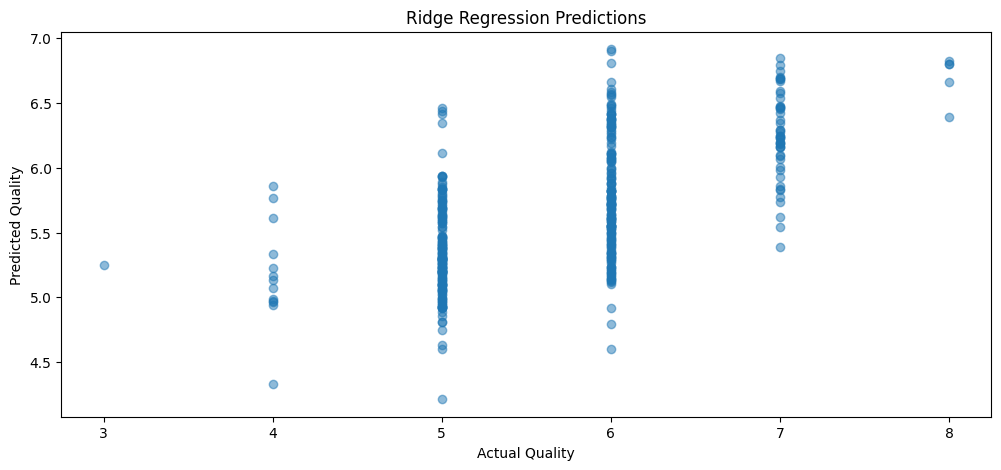

In [28]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

# Separate features and target
X = df.drop(columns='quality')
y = df['quality']

# Create interaction features (all pairwise products)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

# Fit Ridge regression
lin_reg = Ridge(alpha=1.0)
lin_reg.fit(X_train, y_train)

print(f'coefficients: {lin_reg.coef_}')
print(f'intercept: {lin_reg.intercept_}')

train_score = lin_reg.score(X_train, y_train)
test_score = lin_reg.score(X_test, y_test)
print(f"Linear Regression Training R²: {train_score:.3f}")
print(f"Linear Regression Test R²: {test_score:.3f}")

# Predict
y_pred = lin_reg.predict(X_test)

# Visualize predicted vs actual
plt.figure(figsize=(12, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.title('Ridge Regression Predictions')
plt.show()

In [29]:
from sklearn.linear_model import Ridge  # Import Ridge regression model

# Initialize Ridge with specific alpha (regularization strength)
ridge = Ridge(alpha=1.0)  # Create Ridge model, alpha=1.0 (default)
ridge.fit(X_train, y_train)  # Train on training data

# Evaluate performance
train_score_ridge = ridge.score(X_train, y_train)  # R² on training data
test_score_ridge = ridge.score(X_test, y_test)  # R² on test data
print(f"Ridge (alpha=1.0) - Train: {train_score_ridge:.4f}, Test: {test_score_ridge:.4f}")

# Compare with Linear Regression
print(f"Linear Regression - Train: {train_score:.4f}, Test: {test_score:.4f}")
print(f"Difference (Ridge R²): {test_score_ridge - test_score:.4f}")

Ridge (alpha=1.0) - Train: 0.4101, Test: 0.3988
Linear Regression - Train: 0.4101, Test: 0.3988
Difference (Ridge R²): 0.0000


Alpha   0.001: Train R²=0.4202, Test R²=0.3825
Alpha   0.010: Train R²=0.4182, Test R²=0.3834
Alpha   0.100: Train R²=0.4171, Test R²=0.3902
Alpha   1.000: Train R²=0.4101, Test R²=0.3988
Alpha  10.000: Train R²=0.3996, Test R²=0.4013
Alpha 100.000: Train R²=0.3849, Test R²=0.3986
Alpha 1000.000: Train R²=0.3542, Test R²=0.3699


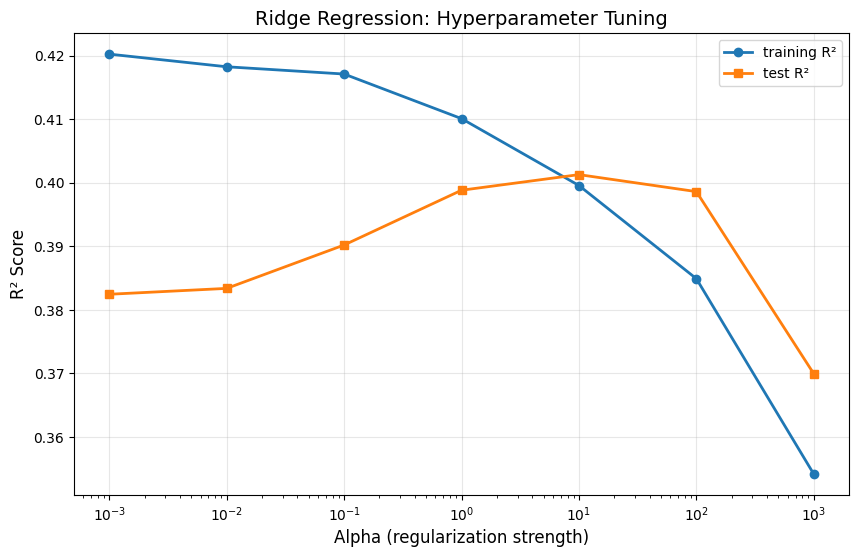


Best alpha: 10 with test R²: 0.4013


In [30]:
# Test different alpha values
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]  # Different regularization strengths
training_scores_ridge = []
test_scores_ridge = []

for alpha in alphas:
    # Create Ridge with specific alpha
    ridge = Ridge(alpha=alpha)
    
    # Train model
    ridge.fit(X_train, y_train)
    
    # Store performance
    training_scores_ridge.append(ridge.score(X_train, y_train))
    test_scores_ridge.append(ridge.score(X_test, y_test))
    
    # Print for each alpha
    print(f"Alpha {alpha:7.3f}: Train R²={ridge.score(X_train, y_train):.4f}, "
          f"Test R²={ridge.score(X_test, y_test):.4f}")

# Plot results with log scale
plt.figure(figsize=(10, 6))
plt.xscale('log')  # Use logarithmic scale for alpha
plt.plot(alphas, training_scores_ridge, marker='o', label="training R²", linewidth=2)
plt.plot(alphas, test_scores_ridge, marker='s', label="test R²", linewidth=2)
plt.ylabel("R² Score", fontsize=12)
plt.xlabel("Alpha (regularization strength)", fontsize=12)
plt.title("Ridge Regression: Hyperparameter Tuning", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

best_alpha = alphas[np.argmax(test_scores_ridge)]
print(f"\nBest alpha: {best_alpha} with test R²: {max(test_scores_ridge):.4f}")

In [31]:
from sklearn.linear_model import Lasso  # Import Lasso model

# Initialize Lasso with specific alpha
lasso = Lasso(alpha=0.1, max_iter=10000)  # max_iter increased to ensure convergence
lasso.fit(X_train, y_train)  # Train on training data

# Evaluate and show feature selection
print(f"Train R²: {lasso.score(X_train, y_train):.4f}")  # Training performance
print(f"Test R²: {lasso.score(X_test, y_test):.4f}")  # Test performance

# For multi-feature data, show feature selection
if X_train.shape[1] > 1:
    n_features_used = np.sum(lasso.coef_ != 0)  # Count non-zero coefficients
    print(f"Features selected: {n_features_used} out of {len(lasso.coef_)}")  # Show selection ratio

Train R²: 0.3121
Test R²: 0.3226
Features selected: 5 out of 66


Alpha  0.001: Train R²=0.3989, Test R²=0.4045
Alpha  0.010: Train R²=0.3791, Test R²=0.3978
Alpha  0.100: Train R²=0.3121, Test R²=0.3226
Alpha  1.000: Train R²=0.0000, Test R²=-0.0020
Alpha 10.000: Train R²=0.0000, Test R²=-0.0020


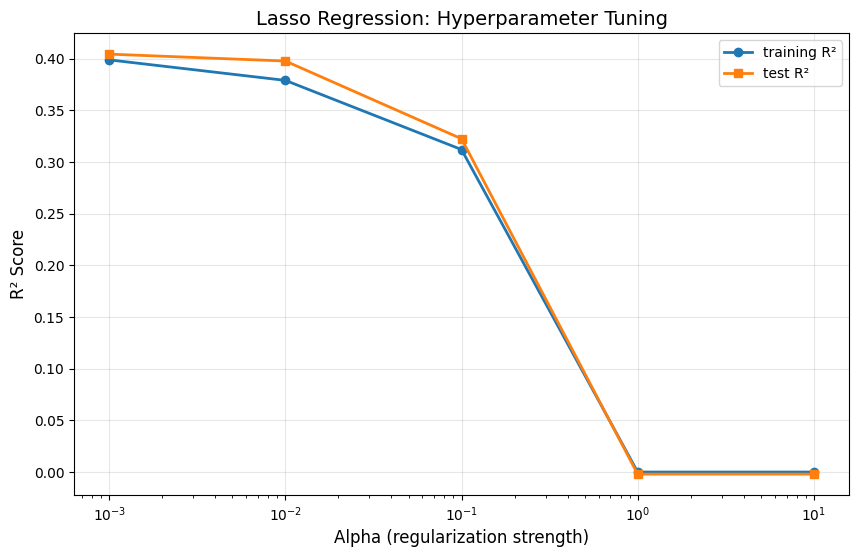

In [33]:
# Test different alpha values for Lasso
alphas_lasso = [0.001, 0.01, 0.1, 1, 10]  # Different regularization strengths
training_scores_lasso = []
test_scores_lasso = []

for alpha in alphas_lasso:
    # Create Lasso with specific alpha
    lasso = Lasso(alpha=alpha, max_iter=100000)
    
    # Train model
    lasso.fit(X_train, y_train)
    
    # Store performance
    train_score_lasso = lasso.score(X_train, y_train)
    test_score_lasso = lasso.score(X_test, y_test)
    training_scores_lasso.append(train_score_lasso)
    test_scores_lasso.append(test_score_lasso)
    
    # Print results
    print(f"Alpha {alpha:6.3f}: Train R²={train_score_lasso:.4f}, Test R²={test_score_lasso:.4f}")

# Plot results
plt.figure(figsize=(10, 6))
plt.xscale('log')  # Logarithmic scale for alpha
plt.plot(alphas_lasso, training_scores_lasso, marker='o', label="training R²", linewidth=2)
plt.plot(alphas_lasso, test_scores_lasso, marker='s', label="test R²", linewidth=2)
plt.ylabel("R² Score", fontsize=12)
plt.xlabel("Alpha (regularization strength)", fontsize=12)
plt.title("Lasso Regression: Hyperparameter Tuning", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

In [37]:
# General imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab as plot

# Validation and Preprocessing
from sklearn.model_selection import train_test_split, KFold, ShuffleSplit, cross_val_score
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import accuracy_score, r2_score, confusion_matrix, classification_report

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor

class SimpleAutoML:
    def __init__(self, task_type='classification'):
        self.task_type = task_type
        
        # Load the models depending on the task
        if self.task_type == 'classification':
            self.models = {
                'Logistic Regression': LogisticRegression(max_iter=10000),
                'Linear SVC': LinearSVC(max_iter=10000),
                'k-NN Classifier': KNeighborsClassifier(n_neighbors=5)
            }
            self.scoring = 'accuracy'
            self.ylabel = 'Accuracy'
        elif self.task_type == 'regression':
            self.models = {
                'Linear Reg': LinearRegression(),
                'Ridge Reg': Ridge(alpha=1.0),
                'Lasso Reg': Lasso(alpha=1.0),
                'k-NN Regressor': KNeighborsRegressor(n_neighbors=5)
            }
            self.scoring = 'r2'
            self.ylabel = 'R2 Score'
        else:
            raise ValueError("task_type must be 'classification' or 'regression'")
            
    def _preprocess(self, X):
        """Step 5 from Data Cleaning Notebook: Bringing features onto the same scale"""
        scaler = StandardScaler()
        return scaler.fit_transform(X)

    def evaluate_3way_split(self, X, y):
        """Splits data into Train (60%), Validation (20%), and Test (20%)."""
        print(f"--- 3-Way Split (Train/Val/Test) ---")
        X_scaled = self._preprocess(X)
        
        # Split 1: 80% Temp (Train+Val), 20% Test
        X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
        # Split 2: 75% Train of Temp (60% total), 25% Val of Temp (20% total)
        X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)
        
        results = {}
        best_model_name = None
        best_score = -np.inf
        
        for name, model in self.models.items():
            model.fit(X_train, y_train)
            val_pred = model.predict(X_val)
            test_pred = model.predict(X_test)
            
            if self.task_type == 'classification':
                val_score = accuracy_score(y_val, val_pred)
                test_score = accuracy_score(y_test, test_pred)
            else:
                val_score = r2_score(y_val, val_pred)
                test_score = r2_score(y_test, test_pred)
                
            results[name] = {'Val Score': val_score, 'Test Score': test_score}
            
            if test_score > best_score:
                best_score = test_score
                best_model_name = name
                best_test_pred = test_pred
                
        df_results = pd.DataFrame(results).T
        display(df_results)
        
        # If classification, show confusion matrix of the best model (Style from NB 3B)
        if self.task_type == 'classification':
            print(f"\nBest Model: {best_model_name}. Plotting Confusion Matrix on Test Data:")
            self._plot_confusion_matrix(y_test, best_test_pred)
            
        return df_results

    def evaluate_kfold(self, X, y, k=5):
        """Standard k-Fold Cross Validation"""
        print(f"\n--- {k}-Fold Cross Validation ---")
        X_scaled = self._preprocess(X)
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        
        return self._run_cv_and_plot(X_scaled, y, kf, f"{k}-Fold CV Comparison")

    def evaluate_monte_carlo(self, X, y, n_splits=10, test_size=0.2):
        """Monte Carlo Cross Validation (ShuffleSplit)"""
        print(f"\n--- Monte Carlo CV ({n_splits} splits) ---")
        X_scaled = self._preprocess(X)
        mc_cv = ShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=42)
        
        return self._run_cv_and_plot(X_scaled, y, mc_cv, f"Monte Carlo CV Comparison ({n_splits} splits)")

    def _run_cv_and_plot(self, X_scaled, y, cv_method, title):
        results = {}
        all_scores = {}
        
        for name, model in self.models.items():
            scores = cross_val_score(model, X_scaled, y, cv=cv_method, scoring=self.scoring)
            results[name] = {'Mean Score': scores.mean(), 'Std Dev': scores.std()}
            all_scores[name] = scores
            
        df_results = pd.DataFrame(results).T
        display(df_results)
        self._plot_errorbar_comparisons(all_scores, title)
        return df_results

    def _plot_errorbar_comparisons(self, all_scores, title):
        """Graphing style adapted from NB 3A Linear Models for Regression"""
        fig = plt.figure(figsize=(10, 6))
        
        params = {'legend.fontsize': 12, 'legend.handlelength': 2}
        plot.rcParams.update(params)
        
        names = list(all_scores.keys())
        means = [scores.mean() for scores in all_scores.values()]
        stds = [scores.std() for scores in all_scores.values()]
        
        plt.errorbar(names, means, yerr=stds, label=f"CV {self.ylabel}", 
                     color='blue', marker='o', linestyle='dashed', markersize=10, capsize=8)
        
        plt.ylabel(self.ylabel, fontsize=15)
        plt.xlabel("Algorithms", fontsize=15)
        plt.title(title, fontsize=18)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    def _plot_confusion_matrix(self, y_true, y_pred):
        """Graphing style adapted from NB 3B Linear Models for Classification"""
        confmat = confusion_matrix(y_true=y_true, y_pred=y_pred)
        fig, ax = plt.subplots(figsize=(2.5, 2.5))
        ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
        for i in range(confmat.shape[0]):
            for j in range(confmat.shape[1]):
                ax.text(x=j, y=i, s=confmat[i, j], va='center', ha='center')
        plt.xlabel('Predicted label')
        plt.ylabel('True label')
        plt.show()

Starting AutoML for Regression...
--- 3-Way Split (Train/Val/Test) ---


,Val Score,Test Score
Linear Reg,0.362157,-0.060560
Ridge Reg,0.400775,0.144895
Lasso Reg,-0.004621,-0.013733
k-NN Regressor,0.318116,0.143141



--- 5-Fold Cross Validation ---


,Mean Score,Std Dev
Linear Reg,0.255189,0.121633
Ridge Reg,0.289369,0.099224
Lasso Reg,-0.008368,0.008447
k-NN Regressor,0.232926,0.051023


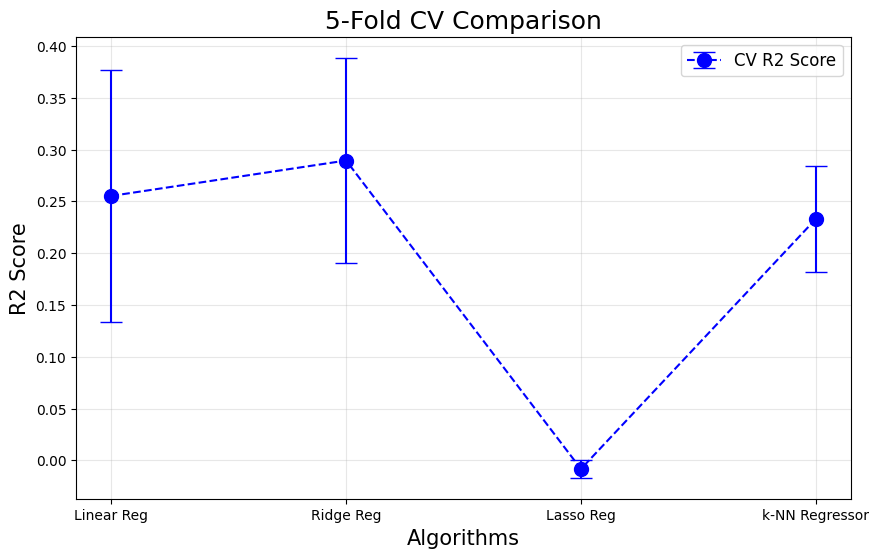


--- Monte Carlo CV (1 splits) ---


,Mean Score,Std Dev
Linear Reg,0.050372,0.0
Ridge Reg,0.132820,0.0
Lasso Reg,-0.009751,0.0
k-NN Regressor,0.162157,0.0


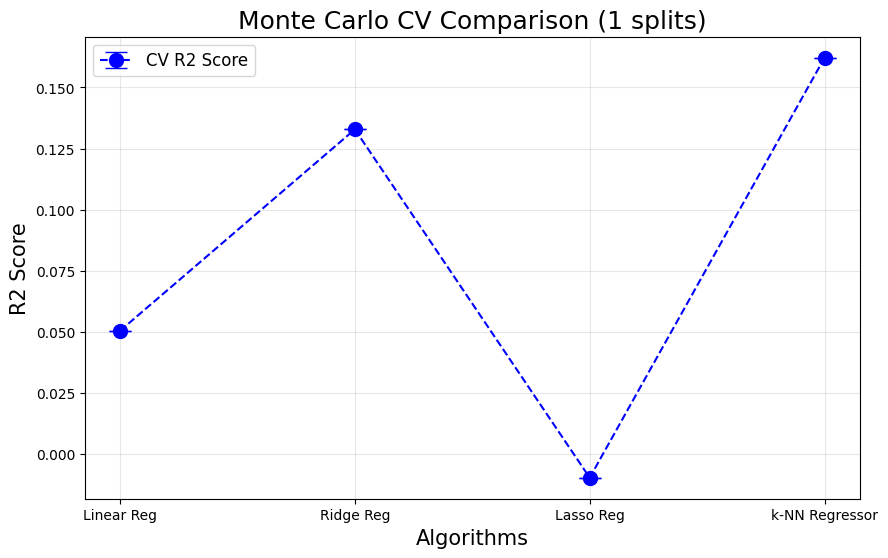

In [41]:
from sklearn.datasets import make_regression

# Generate sample regression dataset

print("Starting AutoML for Regression...")
automl_reg = SimpleAutoML(task_type='regression')

# 1. 3-Way Split Test
results_3way_reg = automl_reg.evaluate_3way_split(X_train, y_train)

# 2. k-Fold Test
results_kfold_reg = automl_reg.evaluate_kfold(X_train, y_train, k=5)

# 3. Monte Carlo Test
results_mc_reg = automl_reg.evaluate_monte_carlo(X_train, y_train, n_splits=1, test_size=0.2)